Phase 1: Dataset Understanding and Cleaning

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("Clean_Dataset.csv")

# First 5 rows
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
# Removing unnecessary index column
df.drop('Unnamed: 0', axis=1, inplace=True)

# Verify dataset
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
# Number of rows and columns
df.shape

(300153, 11)

In [7]:
# Checking data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [8]:
# Checking missing values
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [9]:
# Checking duplicate records
df.duplicated().sum()

np.int64(0)

Phase 2: Exploratory Data Analysis

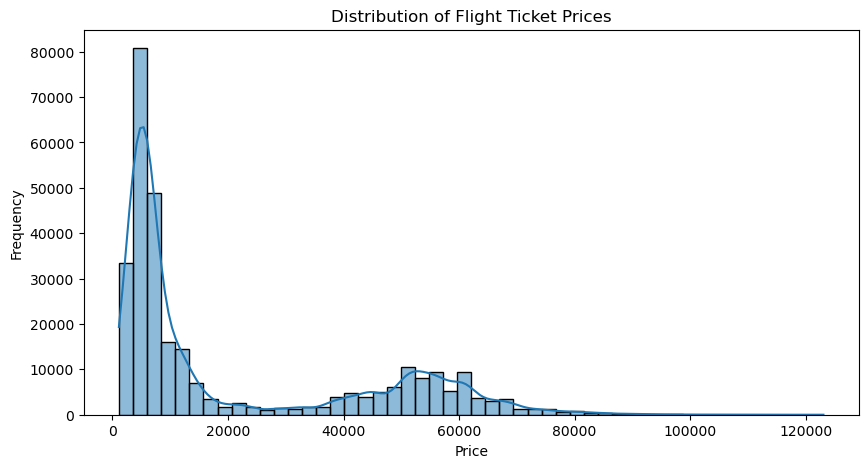

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Flight Ticket Prices

plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Flight Ticket Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

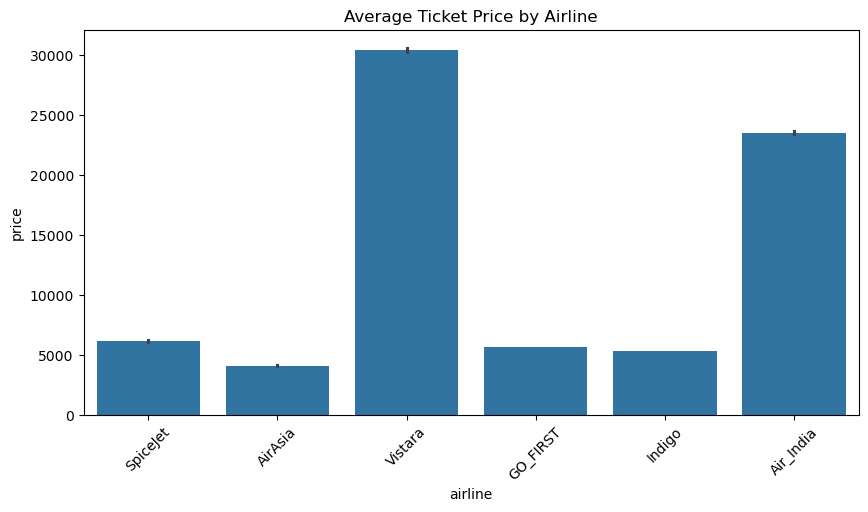

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='airline',
    y='price',
    data=df
)

plt.title('Average Ticket Price by Airline')
plt.xticks(rotation=45)

plt.show()

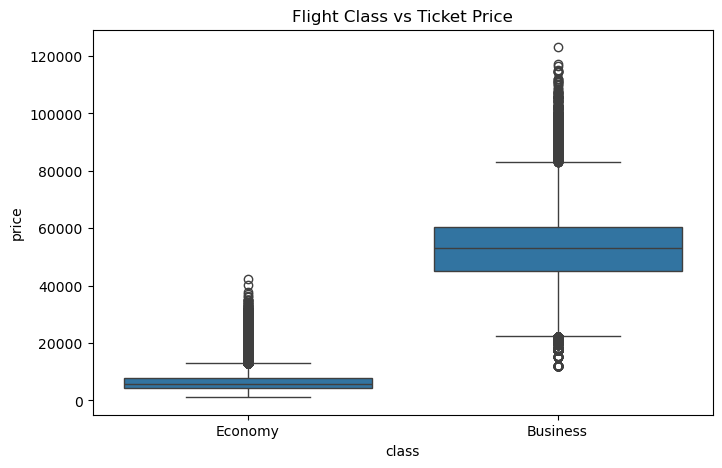

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='class',
    y='price',
    data=df
)

plt.title('Flight Class vs Ticket Price')

plt.show()

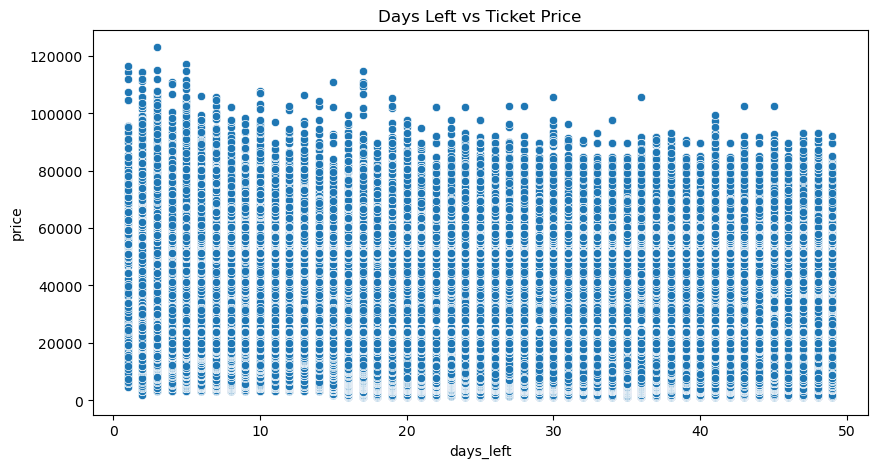

In [14]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='days_left',
    y='price',
    data=df
)

plt.title('Days Left vs Ticket Price')

plt.show()

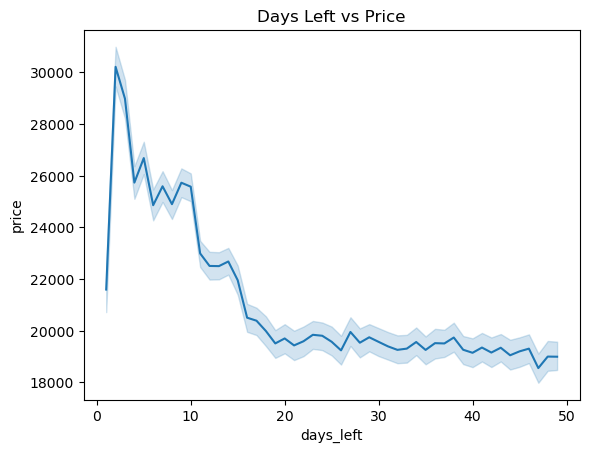

In [30]:
plt.figure()
sns.lineplot(x='days_left', y='price', data=df)
plt.title("Days Left vs Price")
plt.show()

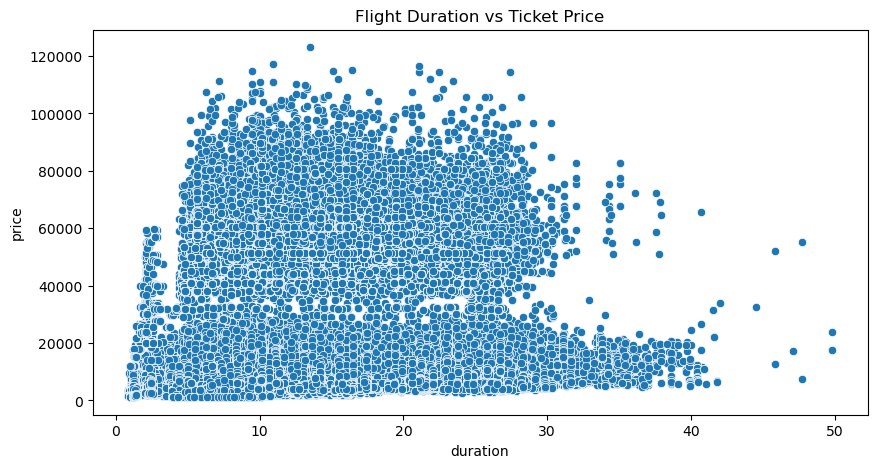

In [15]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='duration',
    y='price',
    data=df
)

plt.title('Flight Duration vs Ticket Price')

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10712\3605962239.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


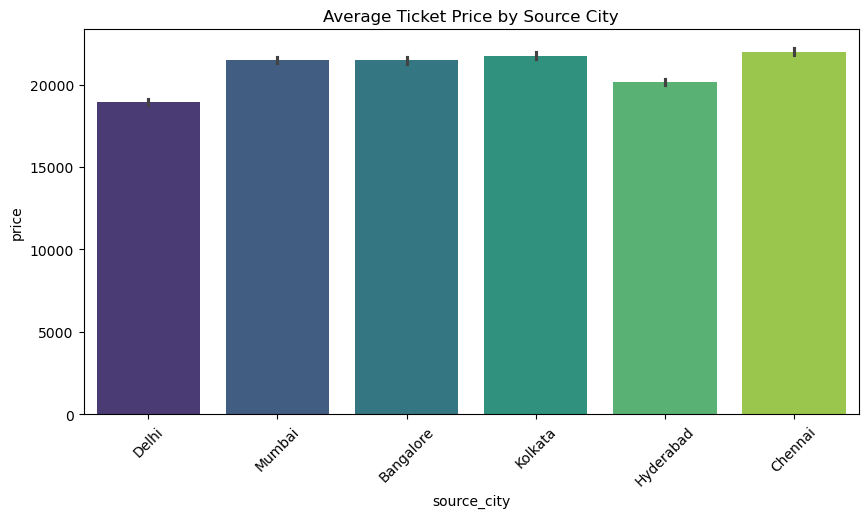

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='source_city',
    y='price',
    data=df,
    palette='viridis'
)

plt.title('Average Ticket Price by Source City')
plt.xticks(rotation=45)

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10712\1809528973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


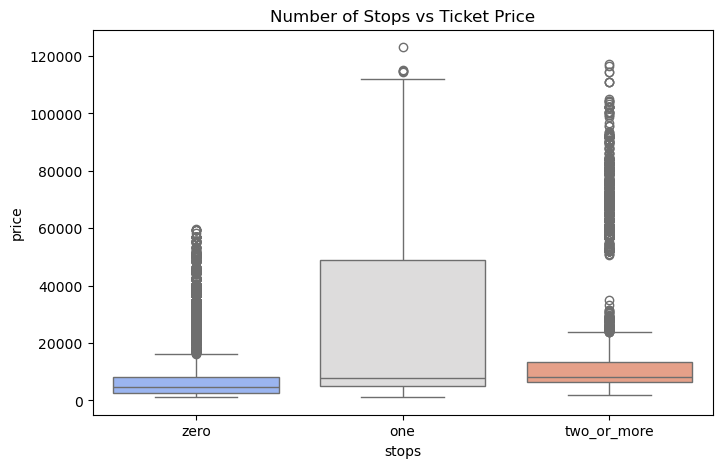

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='stops',
    y='price',
    data=df,
    palette='coolwarm'
)

plt.title('Number of Stops vs Ticket Price')

plt.show()

Feature Engineering& Machine Learning

In [19]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'airline',
    'flight',
    'source_city',
    'departure_time',
    'stops',
    'arrival_time',
    'destination_city',
    'class'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,1408,2,2,2,5,5,1,2.17,1,5953
1,4,1387,2,1,2,4,5,1,2.33,1,5953
2,0,1213,2,1,2,1,5,1,2.17,1,5956
3,5,1559,2,4,2,0,5,1,2.25,1,5955
4,5,1549,2,4,2,4,5,1,2.33,1,5955


In [21]:
# Creating surge column

median_price = df['price'].median()

df['surge'] = (df['price'] > median_price).astype(int)

df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,surge
0,4,1408,2,2,2,5,5,1,2.17,1,5953,0
1,4,1387,2,1,2,4,5,1,2.33,1,5953,0
2,0,1213,2,1,2,1,5,1,2.17,1,5956,0
3,5,1559,2,4,2,0,5,1,2.25,1,5955,0
4,5,1549,2,4,2,4,5,1,2.33,1,5955,0


In [22]:
X = df.drop(['price', 'surge'], axis=1)

y = df['price']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
predictions = rf_model.predict(X_test)

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R² Score:", r2)
print("MAE:", mae)

R² Score: 0.98956606125345
MAE: 862.9665722015187


In [33]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
7             class    0.879552
8          duration    0.048686
1            flight    0.029640
9         days_left    0.017850
6  destination_city    0.009736
2       source_city    0.006164
5      arrival_time    0.002789
3    departure_time    0.002512
4             stops    0.002116
0           airline    0.000955


In [34]:
# Saving cleaned dataset to CSV

df.to_csv("Clean_Flight_Dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [35]:
import pandas as pd

clean_df = pd.read_csv("Clean_Flight_Dataset.csv")

clean_df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,surge
0,4,1408,2,2,2,5,5,1,2.17,1,5953,0
1,4,1387,2,1,2,4,5,1,2.33,1,5953,0
2,0,1213,2,1,2,1,5,1,2.17,1,5956,0
3,5,1559,2,4,2,0,5,1,2.25,1,5955,0
4,5,1549,2,4,2,4,5,1,2.33,1,5955,0
